In [1]:
import sys
sys.path.append('../src')

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# Parameters
lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 100, 1000, 10000]
step = 10000
shape_list = ["biconcave", "bud_04", "multi"]
# shape_list = ["biconcave"]
flip_ratio_list = [0.1, 0.15, 0.2]

# Load checkpoint data
checkpoint_data = {}
for shape in shape_list:
    checkpoint_data[shape] = {}
    for flip_ratio in flip_ratio_list:
        flip_str = str(flip_ratio).replace('.', '')
        checkpoint_data[shape][flip_ratio] = {}
        for lambda_2 in lambda_2_list:
            if shape == "biconcave":
                checkpoint_dir  = os.path.abspath(f"../outputs/logs/{shape}/noisy/flip_{flip_str}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
            else:
                checkpoint_dir  = os.path.abspath(f"../outputs/logs/{shape}/flip/f{flip_str}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
            checkpoint_data[shape][flip_ratio][lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_dir, target=None)

/gscratch/matsulab/envs/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [3]:
## 0: unsuccessful (data)
## 1: successful
## 2: unsuccessful (phys)

state_map = {
    # biconcave
    ("biconcave", 0.1,   0): 1,
    ("biconcave", 0.1,  10): 1,
    ("biconcave", 0.1, 100): 1,
    ("biconcave", 0.1,1000): 1,
    ("biconcave", 0.1,10000): 2,

    ("biconcave", 0.15,   0): 0,
    ("biconcave", 0.15,  10): 0,
    ("biconcave", 0.15, 100): 1,
    ("biconcave", 0.15,1000): 1,
    ("biconcave", 0.15,10000): 2,

    ("biconcave", 0.2,   0): 0,
    ("biconcave", 0.2,  10): 0,
    ("biconcave", 0.2, 100): 1,
    ("biconcave", 0.2,1000): 2,
    ("biconcave", 0.2,10000): 2,

    # bud_04
    ("bud_04", 0.1,   0): 1,
    ("bud_04", 0.1,  10): 1,
    ("bud_04", 0.1,  30): 1,
    ("bud_04", 0.1, 100): 1,
    ("bud_04", 0.1,1000): 2,

    ("bud_04", 0.15,   0): 0,
    ("bud_04", 0.15,  10): 0,
    ("bud_04", 0.15,  30): 0,
    ("bud_04", 0.15, 100): 1,
    ("bud_04", 0.15,1000): 2,

    ("bud_04", 0.2,   0): 0,
    ("bud_04", 0.2,  10): 0,
    ("bud_04", 0.2,  10): 0,
    ("bud_04", 0.2, 100): 1,
    ("bud_04", 0.2,1000): 2,

    # multi
    ("multi", 0.1,   0): 1,
    ("multi", 0.1,  10): 1,
    ("multi", 0.1,  30): 1,
    ("multi", 0.1, 100): 1,
    ("multi", 0.1,1000): 2,

    ("multi", 0.15,   0): 0,
    ("multi", 0.15,  10): 0,
    ("multi", 0.15,  30): 1,
    ("multi", 0.15, 100): 1,
    ("multi", 0.15,1000): 1,

    ("multi", 0.2,   0): 0,
    ("multi", 0.2,  10): 0,
    ("multi", 0.2,  30): 0,
    ("multi", 0.2, 100): 1,
    ("multi", 0.2,1000): 2,
}


state_markers = {
    0: "o",   # circle
    1: "s",   # square
    2: "D",   # diamond
}


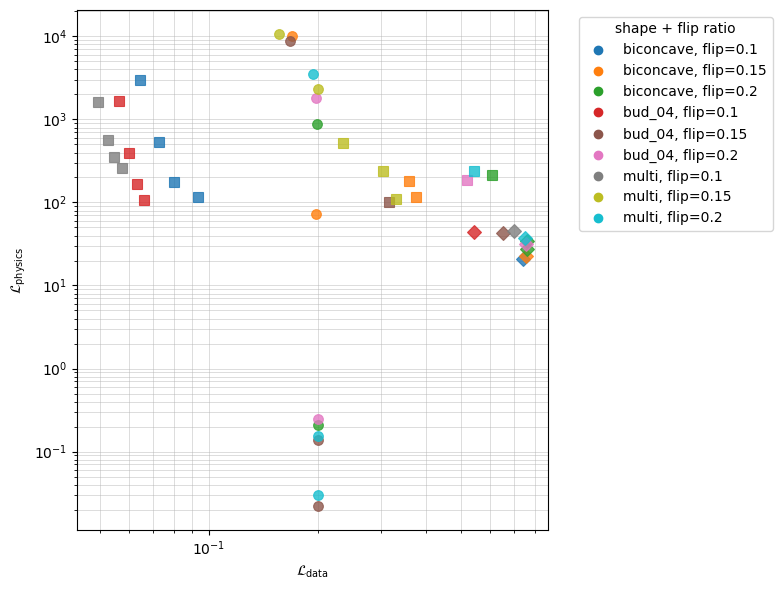

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Assign consistent colors to (shape, flip_ratio)
pairs = [(s, fr) for s in shape_list for fr in flip_ratio_list]
cmap = plt.get_cmap("tab10", len(pairs))
color_map = {pair: cmap(i) for i, pair in enumerate(pairs)}

plt.figure(figsize=(8, 6))

flip_ratio_list_fig = [0.1, 0.15, 0.2]
# flip_ratio_list_fig = [0.15, 0.2]
lambda_2_list_fig = [0, 10, 30, 100, 1000, 10000]

for shape in shape_list:
    for flip_ratio in flip_ratio_list_fig:
        series_color = color_map[(shape, flip_ratio)]
        for lambda_2 in lambda_2_list_fig:
            ckpt = checkpoint_data[shape][flip_ratio][lambda_2]
            if ckpt is None:
                continue
            x_val = ckpt['loss']['data_loss'][-1]
            y_val = ckpt['loss']['physics_loss'][-1]
            # y_val = ckpt['loss']['physics_loss'][-1] * lambda_2
            # x_val = lambda_2
            # y_val = ckpt['loss']['physics_loss'][-1] * lambda_2 / ckpt['loss']['data_loss'][-1]
            # x_val = flip_ratio
            # y_val = ckpt['loss']['data_loss'][-1]
            state = state_map.get((shape, flip_ratio, lambda_2), None)
            if state is None:
                continue
            marker_style = state_markers[state]
            plt.plot(
                x_val, y_val,
                marker=marker_style,
                alpha = 0.8,
                linestyle="",
                markersize=7,
                markeredgewidth=0.8,
                color=series_color,
            )

# plt.xscale("symlog", linthresh=1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\mathcal{L}_\mathrm{data}$")
plt.ylabel(r"$\mathcal{L}_\mathrm{physics}$")
# plt.xlabel(r"flip_ratio")
# plt.ylabel(r"$\mathcal{L}_\mathrm{data}$")
# plt.ylabel("physics_loss (last step)")
# plt.title("Physics loss vs $\\lambda_2$")
plt.grid(True, which="both", linewidth=0.5, alpha=0.6)

# --- Legend only for colors (shape + flip) ---
color_handles = [
    Line2D([0], [0], color=color_map[(s, fr)], marker="o", linestyle="",
           label=f"{s}, flip={fr}")
    for (s, fr) in pairs
]
plt.legend(handles=color_handles, title="shape + flip ratio",
           bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()



In [9]:
## For clean input

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# Parameters
lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 100, 1000, 10000]
step = 10000
shape_list = ["biconcave", "bud_04", "multi"]

# Load checkpoint data
checkpoint_data = {}
for shape in shape_list:
    checkpoint_data[shape] = {}
    for lambda_2 in lambda_2_list:
        checkpoint_dir  = os.path.abspath(f"../outputs/logs/{shape}/clean/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
        checkpoint_data[shape][lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_dir, target=None)




/gscratch/matsulab/envs/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [21]:
## 0: unsuccessful (data)
## 1: successful
## 2: unsuccessful (phys)

state_map = {
    ("biconcave",   0): 1,
    ("biconcave",  10): 1,
    ("biconcave", 100): 1,
    ("biconcave",1000): 1,

    ("bud_04",   0): 1,
    ("bud_04",  10): 1,
    ("bud_04", 100): 1,
    ("bud_04",1000): 2,

    ("multi",   0): 1,
    ("multi",  10): 1,
    ("multi", 100): 1,
    ("multi",1000): 2,
}


state_markers = {
    0: "o",   # circle
    1: "s",   # square
    2: "D",   # diamond
}


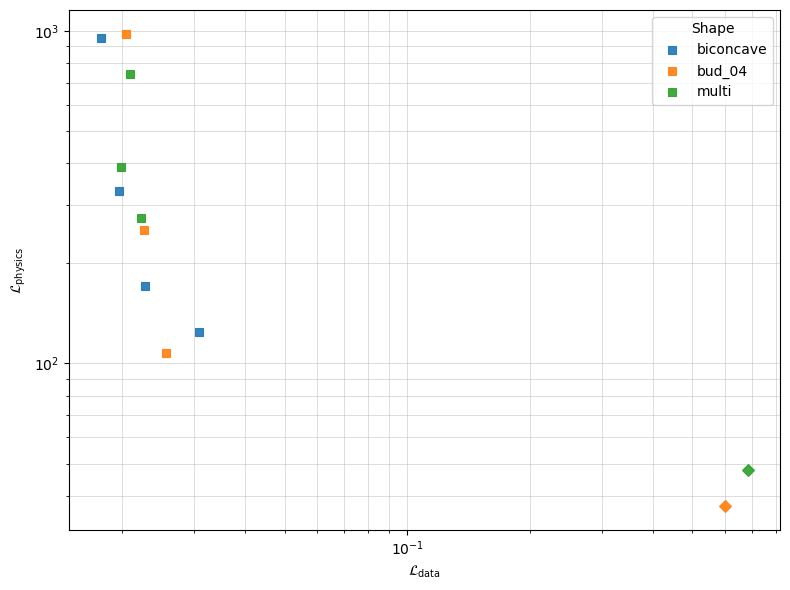

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# distinct palette
colors = plt.cm.tab10.colors
color_map = {shape: colors[i % len(colors)] for i, shape in enumerate(shape_list)}

for shape in shape_list:
    for lam in [0, 10, 30, 100, 1000, 10000]:
        ckpt = checkpoint_data.get(shape, {}).get(lam)
        if not ckpt:
            continue
        try:
            x = float(ckpt['loss']['data_loss'][-1])
            y = float(ckpt['loss']['physics_loss'][-1])
        except Exception:
            continue
        if x <= 0 or y <= 0:
            continue

        # pick marker from state_map
        state = state_map.get((shape, lam), None)
        marker = state_markers.get(state, "o")  # fallback = circle

        plt.plot(
            x, y,
            linestyle="",
            marker=marker,
            markersize=6,
            markeredgewidth=0.8,
            alpha=0.9,
            color=color_map[shape],
            label=shape if lam == 0 else ""  # only label once
        )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\mathcal{L}_\mathrm{data}$")
plt.ylabel(r"$\mathcal{L}_\mathrm{physics}$")
plt.grid(True, which="both", linewidth=0.5, alpha=0.6)

plt.legend(title="Shape", frameon=True)
plt.tight_layout()
plt.show()



In [2]:
## Trial_0919

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# Parameters
lambda_1 = 1000000
lambda_2_list = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# step = 10000
step = 6000
shape = "bud_04"
flip_ratio = 0.175

# Load checkpoint data
checkpoint_data = {}
flip_str = str(flip_ratio).replace('.', '')
for lambda_2 in lambda_2_list:
    # checkpoint_dir  = os.path.abspath(f"../outputs/logs/{shape}/trial_0919/flip_{flip_str}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
    checkpoint_dir  = os.path.abspath(f"../outputs/logs/{shape}/flip/f{flip_str}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
    checkpoint_data[lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_dir, target=None)




/gscratch/matsulab/envs/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


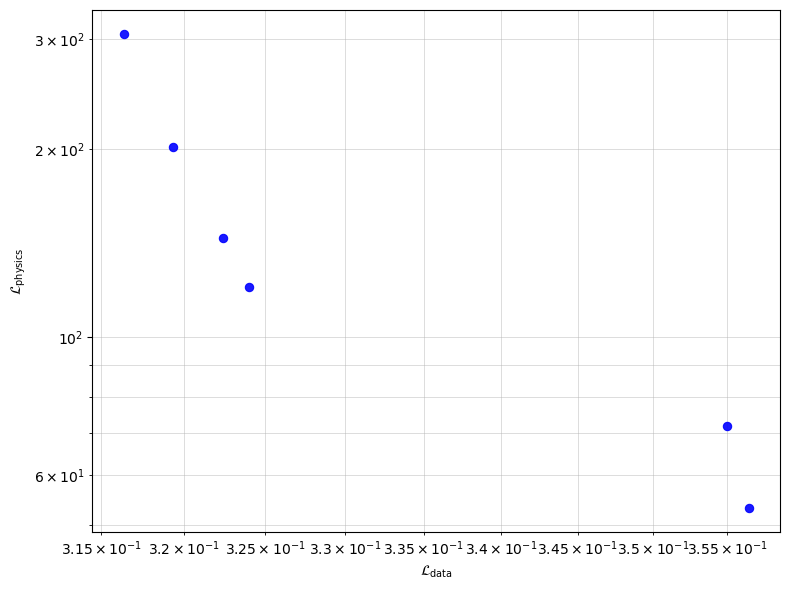

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for lambda_2 in lambda_2_list:
    ckpt = checkpoint_data.get(lambda_2)
    if not ckpt:
        continue
    try:
        x = float(ckpt['loss']['data_loss'][-1])
        y = float(ckpt['loss']['physics_loss'][-1])
    except Exception:
        continue
    if x <= 0 or y <= 0:
        continue

    plt.plot(
        x, y,
        linestyle="",
        marker="o",
        markersize=6,
        markeredgewidth=0.8,
        alpha=0.9,
        color="blue",
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\mathcal{L}_\mathrm{data}$")
plt.ylabel(r"$\mathcal{L}_\mathrm{physics}$")
plt.grid(True, which="both", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()
